Median length for ZymoBIOMICS Mock Community: 21273.0
Mean length for ZymoBIOMICS Mock Community: 27831.486206896552
Median length for Simulated Gut: 6729.5
Mean length for Simulated Gut: 22119.16
Median length for Environmental Mock Community: 11510.0
Mean length for Environmental Mock Community: 25944.383905013194
Median length for Simulated Wastewater: 9195.5
Mean length for Simulated Wastewater: 30154.364285714284
Median length for Simulated Soil: 5637.75
Mean length for Simulated Soil: 8591.737268518518
Median proportion-query-genes-found for Simulated Soil: 0.75
Median proportion-query-genes-found for Simulated Gut: 0.958
Median proportion-query-genes-found for Simulated Wastewater: 0.975
Median proportion-query-genes-found for Environmental Mock Community: 1.0
Median proportion-query-genes-found for ZymoBIOMICS Mock Community: 0.971


/tmp/ipykernel_3141111/2625612756.py:59: UserWarning: The palette list has more values (8) than needed (5), which may not be intended.
  sns.kdeplot(data=all_summarized, x='path_length', hue='Dataset', palette=["#1B9E77FF", "#D95F02FF", "#7570B3FF", "#E7298AFF", "#66A61EFF", "#E6AB02FF", "#A6761DFF", "#ffffff"], log_scale=True, linewidth=4, ax=ax1)
/tmp/ipykernel_3141111/2625612756.py:65: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dataset', y='proportion-query-genes-found', data=combined_data, palette='Dark2', width=0.5, ax=ax2)
/tmp/ipykernel_3141111/2625612756.py:67: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')


Median avg-syntenic-correlation for Simulated Soil: 0.999
Median avg-syntenic-correlation for Simulated Gut: 1.0
Median avg-syntenic-correlation for Simulated Wastewater: 1.0
Median avg-syntenic-correlation for Environmental Mock Community: 1.0
Median avg-syntenic-correlation for ZymoBIOMICS Mock Community: 1.0
Median avg-syntenic-correlation for all datasets combined: 1.0


/tmp/ipykernel_3141111/2625612756.py:83: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Dataset', y='avg-syntenic-correlation', data=combined_data, palette='Dark2', width=0.5)


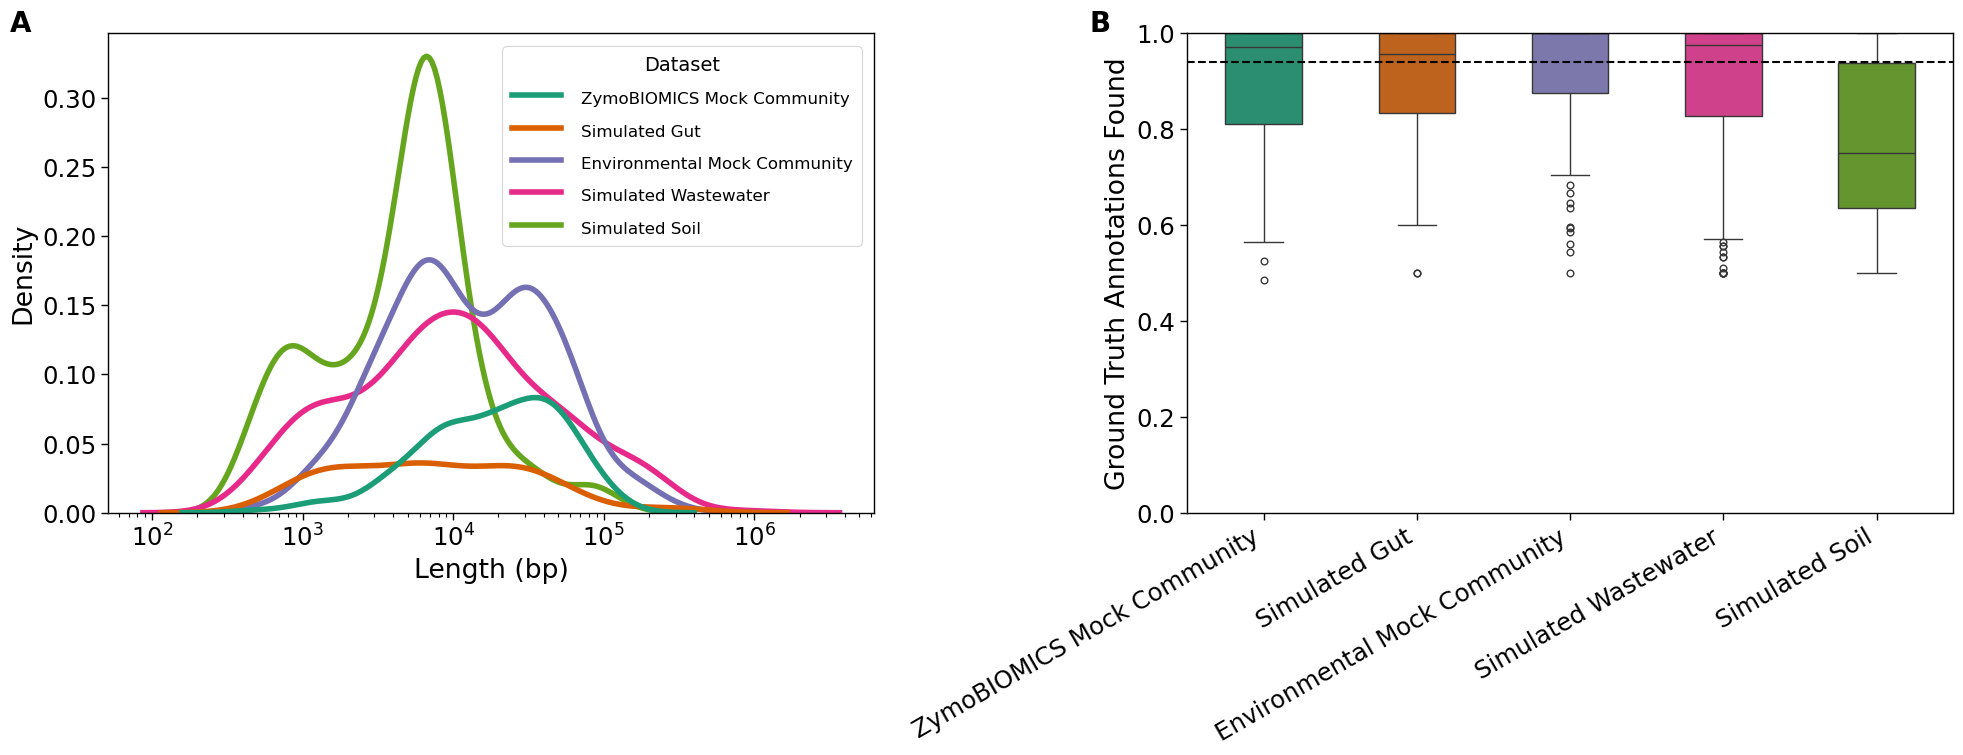

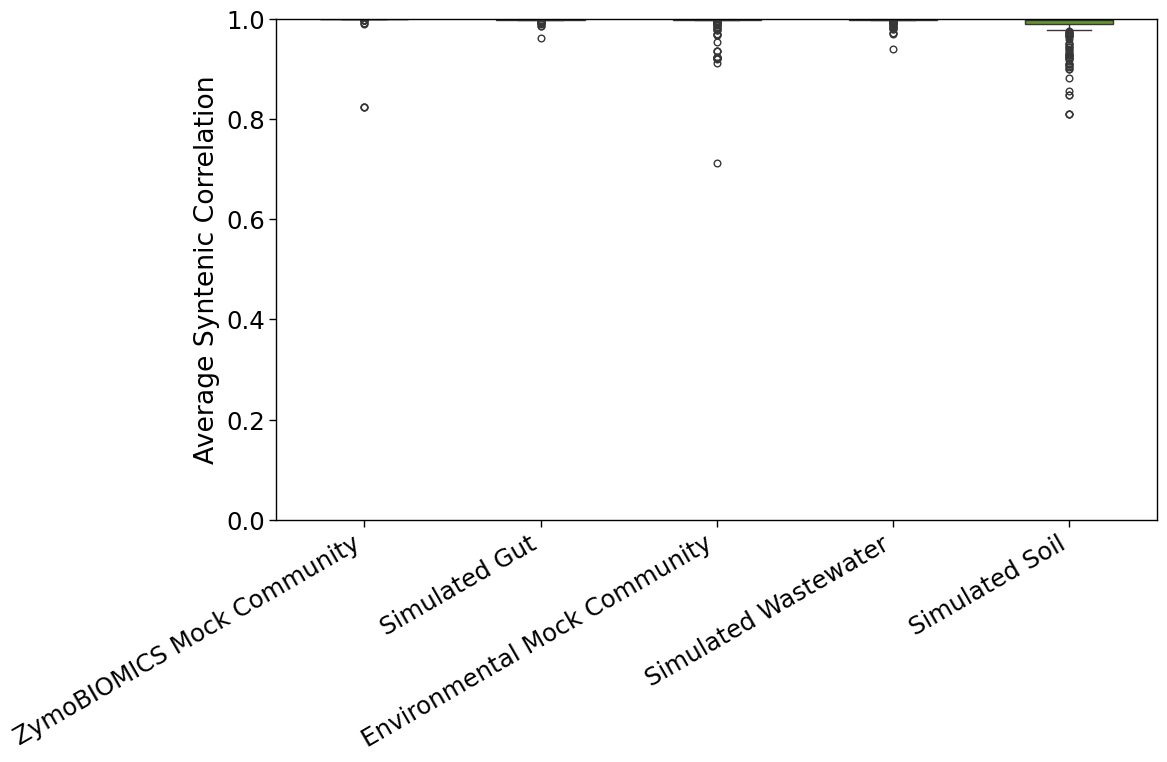

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# read in summarized metadata files for length 
zym_summarized = pd.read_csv("../summarized_metadata/zym_SR_summarized.tsv", sep='\t')
HC_summarized = pd.read_csv("../summarized_metadata/HC_SR_summarized.tsv", sep='\t')
gutss_summarized = pd.read_csv("../summarized_metadata/gutss_SR_summarized.tsv", sep='\t')
ww_summarized = pd.read_csv("../summarized_metadata/ww_SR_summarized.tsv", sep='\t')
hc227_summarized = pd.read_csv('../summarized_metadata/hc227_SR_summarized.tsv', sep='\t')
all_summarized = pd.concat([zym_summarized, gutss_summarized, hc227_summarized, ww_summarized, HC_summarized])

# change "dataset" column name to "Dataset"
all_summarized.rename(columns={'dataset': 'Dataset'}, inplace=True)

# read in fai outputs for correctness
gut_SR = pd.read_csv('../fai_correctness/gut_SR_fai_out.tsv', sep='\t')
ww_SR = pd.read_csv('../fai_correctness/ww_SR_fai_out.tsv', sep='\t')
hc227_SR = pd.read_csv('../fai_correctness/hc227_SR_fai_out.tsv', sep='\t')
RZ_SR = pd.read_csv('../fai_correctness/RZ_SR_fai_out.tsv', sep='\t')
HC_SR = pd.read_csv('../fai_correctness/HC_SR_fai_out.tsv', sep='\t')
# combine all dataframes into one, add a column for dataset
gut_SR['Dataset'] = 'Simulated Gut'
ww_SR['Dataset'] = 'Simulated Wastewater'
hc227_SR['Dataset'] = 'Environmental Mock Community'
RZ_SR['Dataset'] = 'ZymoBIOMICS Mock Community'
HC_SR['Dataset'] = 'Simulated Soil'

combined_data = pd.concat([gut_SR, ww_SR, hc227_SR, RZ_SR, HC_SR], ignore_index=True)

# for instances where there are duplicate "queried_path" entries, take the higher "proportion-query-genes-found" value
combined_data = combined_data.sort_values(by='proportion-query-genes-found', ascending=False).drop_duplicates(subset='queried_path', keep='first')

# separate the queried_path column by _ into three new columns
combined_data[['subgraph', 'tmp', 'path_num', 'trimmed']] = combined_data['queried_path'].str.split('_', expand=True)
combined_data.drop(columns=['tmp', 'queried_path', 'trimmed'], inplace=True)

# reorder dataset categories to: Simulated Gut, Simulated Wastewater, Simulated Soil, ZymoBIOMICS Mock Community, Environmental Mock Community
combined_data['Dataset'] = pd.Categorical(combined_data['Dataset'], categories=['ZymoBIOMICS Mock Community', 'Simulated Gut', 'Environmental Mock Community', 'Simulated Wastewater', 'Simulated Soil'], ordered=True)

# print median length for each dataset
for dataset in all_summarized['Dataset'].unique():
    median_length = all_summarized[all_summarized['Dataset'] == dataset]['path_length'].median()
    mean_length = all_summarized[all_summarized['Dataset'] == dataset]['path_length'].mean()
    print(f'Median length for {dataset}: {median_length}')
    print(f'Mean length for {dataset}: {mean_length}')
# print median proportion-query-genes-found for each dataset
for dataset in combined_data['Dataset'].unique():
    median_proportion = combined_data[combined_data['Dataset'] == dataset]['proportion-query-genes-found'].median()
    print(f'Median proportion-query-genes-found for {dataset}: {median_proportion}')

# combine the two plots into a single figure with two subplots
sns.set_context("paper", font_scale=2)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 8))
# add A abd B labels to the subplots
ax1.text(-0.1, 1.05, 'A', transform=ax1.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')
ax2.text(-0.1, 1.05, 'B', transform=ax2.transAxes, fontsize=20, fontweight='bold', va='top', ha='right')
sns.kdeplot(data=all_summarized, x='path_length', hue='Dataset', palette=["#1B9E77FF", "#D95F02FF", "#7570B3FF", "#E7298AFF", "#66A61EFF", "#E6AB02FF", "#A6761DFF", "#ffffff"], log_scale=True, linewidth=4, ax=ax1)
# make the legend for the kdeplot smaller and move it to the upper right corner of the plot
plt.setp(ax1.get_legend().get_texts(), fontsize='12')
plt.setp(ax1.get_legend().get_title(), fontsize='14')
ax1.set_xlabel('Length (bp)')
ax1.set_ylabel('Density')
sns.boxplot(x='Dataset', y='proportion-query-genes-found', data=combined_data, palette='Dark2', width=0.5, ax=ax2)
ax2.axhline(y=0.94, color='black', linestyle='--', linewidth=1.5)
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=30, ha='right')
ax2.set_xlabel('')
ax2.set_ylabel('Ground Truth Annotations Found')
ax2.set_ylim(0, 1)
plt.tight_layout()
plt.savefig('../figures_tables/figure_2.png', dpi=300)

# print median avg-syntenic-correlation for each dataset and all datasets combined
for dataset in combined_data['Dataset'].unique():
    median_correlation = combined_data[combined_data['Dataset'] == dataset]['avg-syntenic-correlation'].median()
    print(f'Median avg-syntenic-correlation for {dataset}: {median_correlation}')
median_correlation_all = combined_data['avg-syntenic-correlation'].median()
print(f'Median avg-syntenic-correlation for all datasets combined: {median_correlation_all}')

# plot avg-syntenic-correlation as a boxplot for all datasets combined, coloured by dataset
plt.figure(figsize=(12, 8))
sns.boxplot(x='Dataset', y='avg-syntenic-correlation', data=combined_data, palette='Dark2', width=0.5)
plt.xlabel('')
plt.xticks(rotation=30, ha='right')
plt.ylabel('Average Syntenic Correlation')
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig('../figures_tables/figure_S1.png', dpi=300)